In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# data-Driven Insights and Prediction Models for Hotel Booking
# Domain: Travel
# Problem Statement
# It is a classification problem
 The industry faces challenges in understanding and predicting customer booking behavior, which directly impacts revenue management, staffing, inventory planning, and customer satisfaction. Despite accumulating large volumes of booking data, many hotels struggle to derive actionable insights and anticipate cancellations, booking lead times, or peak seasons effectively. This project aims to analyze and model hotel booking patterns using a real-world dataset, enabling stakeholders to optimize operations and make informed decisions.

In [ ]:
url='https://raw.githubusercontent.com/Navenkumar1401/Hotel-booking/refs/heads/main/hotel_bookings.csv'

# Objective

1.Predict booking cancellation (is_canceled column).

2.Understand which features (lead time, previous cancellations, booking channel, etc.)

3.Provide actionable insights to hotel management.




# Actionable Business Insights

i.Identify peak booking periods(by month, season, or event)to plan marketing and staffing.

ii.Uncover cancellation patterns and factors that most influence cancellations

iii.Understand customer profiles (solo travelers, families, business guests) to tailor promotions and room offerings.

iv.Reveal top-performing booking channels to optimize partnerships and advertising spend.

# Brainstorm
1.Lead Time vs. Cancellation: Do longer lead times lead to more cancellations?

2.Booking Patterns by Month: Which months have the highest/lowest bookings or cancellations?

3.Weekday vs Weekend Stays: Are people more likely to book on weekends or weekdays?

4.Repeat Guest Behavior: What’s the behavior difference between repeat and new guests?

5.Booking Changes: How often do guests change reservations (e.g., changes in stay duration)?






Predict if a booking will be canceled (binary classification)
Target variable: is_canceled (0 or 1)

Recommended Algorithms:

Logistic Regression

Random Forest Classifier

XGBoost

Support Vector Machine (SVM)

In [ ]:
# Load the dataset
df=pd.read_csv(url)

# Dataset Selection with Inital EDA

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-2015


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-2015


In [ ]:
# dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

# Feature Discription

| **Feature Name**                 | **Description**                                                                 |
| -------------------------------- | ------------------------------------------------------------------------------- |
| `hotel`                          | Type of hotel: either **City Hotel** or **Resort Hotel**                        |
| `is_canceled`                    | Booking status: **1 = Canceled**, **0 = Not Canceled**                          |
| `lead_time`                      | Number of days between booking date and arrival date                            |
| `arrival_date_year`              | Year of arrival                                                                 |
| `arrival_date_month`             | Month of arrival (e.g., "July")                                                 |
| `arrival_date_week_number`       | Week number of the year (1–52)                                                  |
| `arrival_date_day_of_month`      | Day of the month the guest is scheduled to arrive                               |
| `stays_in_weekend_nights`        | Number of weekend nights (Saturday or Sunday) the guest stayed                  |
| `stays_in_week_nights`           | Number of weeknights (Monday–Friday) the guest stayed                           |
| `adults`                         | Number of adults included in the booking                                        |
| `children`                       | Number of children included in the booking                                      |
| `babies`                         | Number of babies included in the booking                                        |
| `meal`                           | Type of meal booked (e.g., BB = Bed & Breakfast, HB = Half Board)               |
| `country`                        | Country of origin of the guest                                                  |
| `market_segment`                 | Market segment designation (e.g., Direct, Corporate, Online TA)                 |
| `distribution_channel`           | Booking distribution channel (e.g., Direct, TA/TO = Travel Agent/Tour Operator) |
| `is_repeated_guest`              | **1 = Yes**, the guest has stayed before; **0 = No**                            |
| `previous_cancellations`         | Number of previous bookings that were canceled by the customer                  |
| `previous_bookings_not_canceled` | Number of previous bookings not canceled                                        |
| `reserved_room_type`             | Code of the room type initially reserved                                        |
| `assigned_room_type`             | Code of the room type actually assigned                                         |
| `booking_changes`                | Number of changes made to the booking                                           |
| `deposit_type`                   | Deposit type: **No Deposit**, **Refundable**, or **Non Refund**                 |
| `agent`                          | ID of the travel agent who made the booking (can be missing)                    |
| `company`                        | ID of the company that made the booking (can be missing)                        |
| `days_in_waiting_list`           | Number of days the booking was on the waiting list                              |
| `customer_type`                  | Type of customer: **Transient**, **Contract**, etc.                             |
| `adr`                            | **Average Daily Rate** (i.e., revenue per night per room)                       |
| `required_car_parking_spaces`    | Number of car parking spaces required by the guest                              |
| `total_of_special_requests`      | Number of special requests made (e.g., high floor, late check-in)               |
| `reservation_status`             | Status at time of data collection: **Check-Out**, **Canceled**, **No-Show**     |
| `reservation_status_date`        | Date the reservation was marked as complete, canceled, or no-show               |


In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


# Sum of Missing Values

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# shape of a dataset
df.shape

(119390, 32)

(119390, 32)

# Count of target variable

In [ ]:
display(df['is_canceled'].value_counts())

,count
is_canceled,
0,75166
1,44224


,count
is_canceled,
0,75166
1,44224


# Distribution of Target Variable

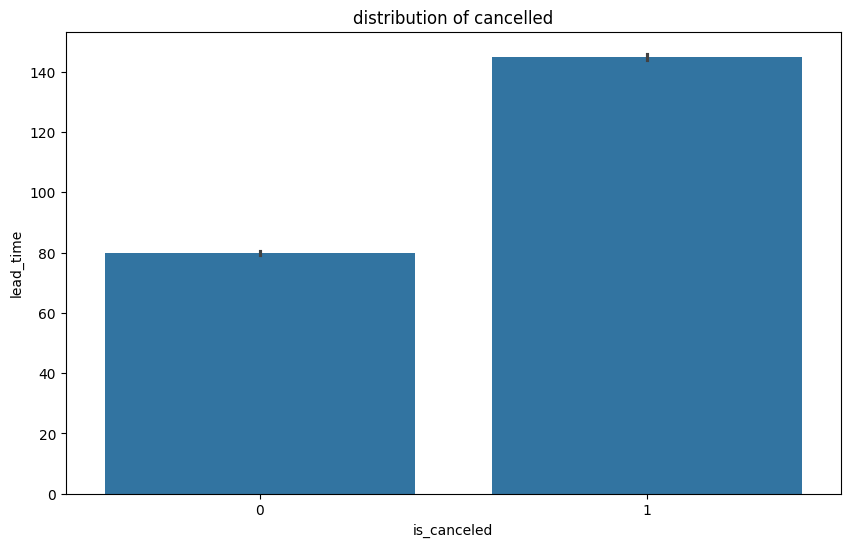

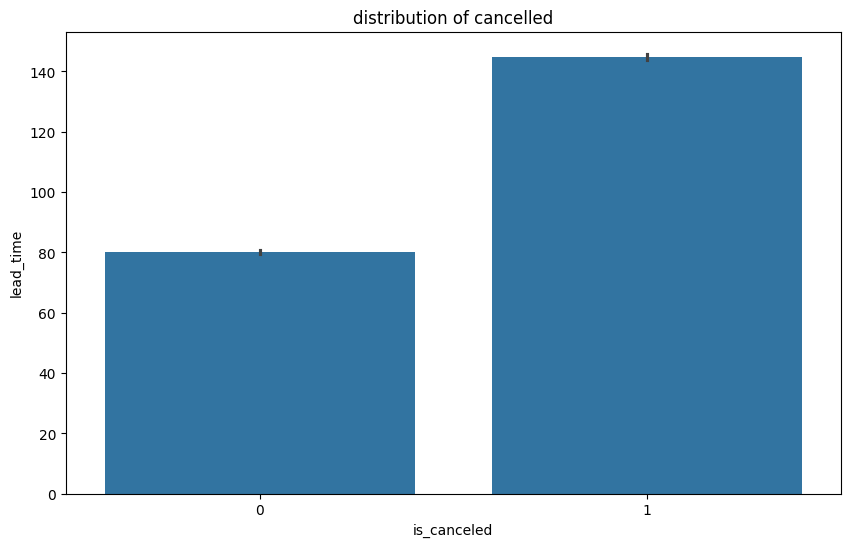

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='is_canceled',y='lead_time',data=df)
plt.title('distribution of cancelled')
plt.xlabel('is_canceled')
plt.ylabel('lead_time')
plt.show()

# Visualization analysis

Percentage cancelation=  0.37041628277075134
reservation_status
Check-Out    62.958372
Canceled     36.030656
No-Show       1.010972
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Reservation status VS Cancellations')

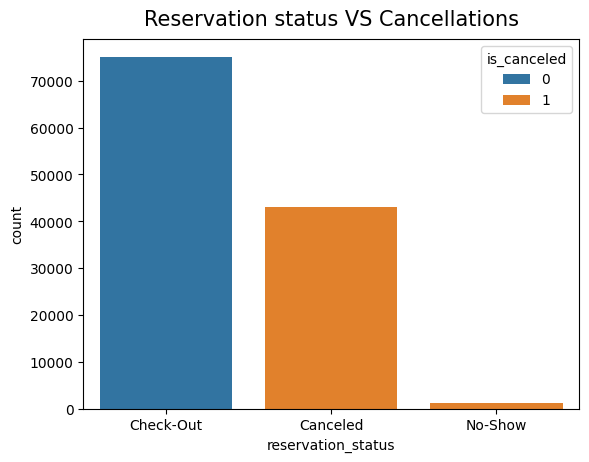

Percentage cancelation=  0.37041628277075134
reservation_status
Check-Out    62.958372
Canceled     36.030656
No-Show       1.010972
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Reservation status VS Cancellations')

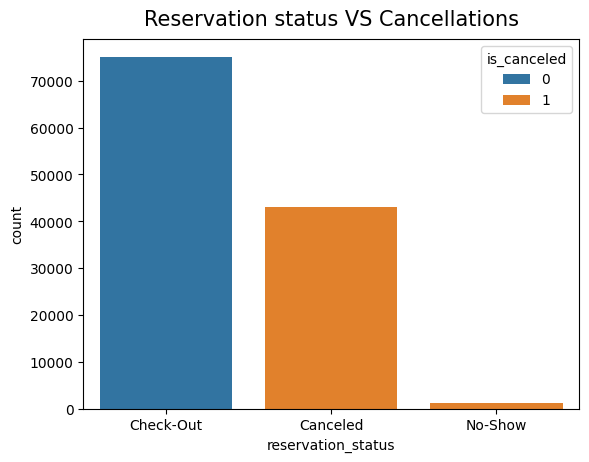

In [ ]:
is_can = len(df[df['is_canceled'] == 1])
print("Percentage cancelation= ", is_can / len(df))
cancellation_types = df['reservation_status'].value_counts(normalize = True) * 100
print(cancellation_types)

# to show the reservation status vs cancelled
sns.countplot(data=df, x = 'reservation_status', hue = 'is_canceled')
plt.title("Reservation status VS Cancellations", fontsize = 15, pad = 10)

In [ ]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric = df_numeric.dropna()
corr= df_numeric.corr(method = 'pearson')['is_canceled'][1:]
corr.sort_values(ascending = False)

,is_canceled
children,0.027563
booking_changes,0.015698
arrival_date_day_of_month,0.002215
arrival_date_week_number,-0.003159
is_repeated_guest,-0.011839
previous_bookings_not_canceled,-0.012140
previous_cancellations,-0.019837
adults,-0.032118
agent,-0.034460
lead_time,-0.039767


,is_canceled
children,0.027563
booking_changes,0.015698
arrival_date_day_of_month,0.002215
arrival_date_week_number,-0.003159
is_repeated_guest,-0.011839
previous_bookings_not_canceled,-0.012140
previous_cancellations,-0.019837
adults,-0.032118
agent,-0.034460
lead_time,-0.039767


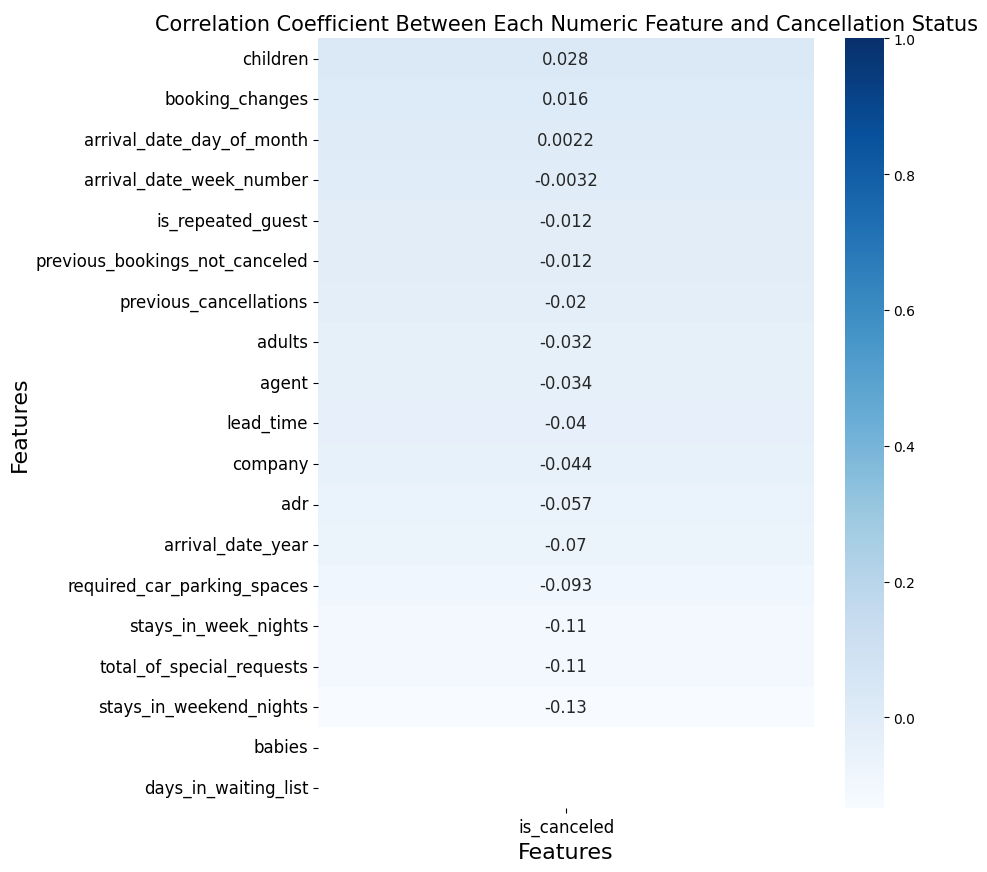

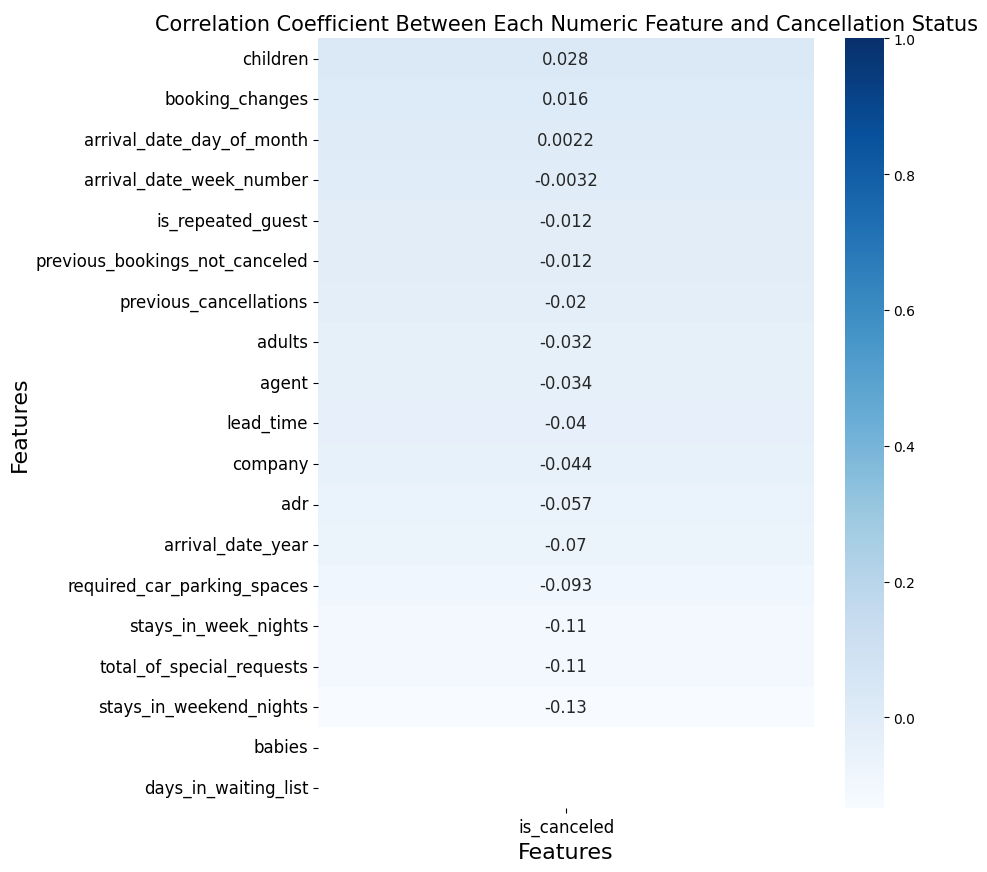

In [ ]:
fig = plt.figure(figsize=(8,10))
ax = sns.heatmap(df_numeric.corr()[['is_canceled']].sort_values('is_canceled', ascending=False), annot = True, annot_kws = {"size":12}, cmap='Blues')
ax.set_title('Correlation Coefficient Between Each Numeric Feature and Cancellation Status', fontsize=15)
ax.set_xlabel('Features', fontsize = 16)
ax.set_ylabel('Features', fontsize = 16)
ax.tick_params(axis = "both", labelsize = 12);
y_min, y_max = ax.get_ylim()
ax.set_ylim(top=y_max+1);

highest positive correlations : lead_time followed by previous_cancellations
highest negative correlations: total_of_special_requestsrequired_car_parking_spaces

# EDA (Visualization) and Pre-processing

Cancellations in resort hotel=  0.27763354967548676
Cancellations in city hotel=  0.41726963317786464


Text(0.5, 1.0, 'Total count of bookings and cancellations per hotel')

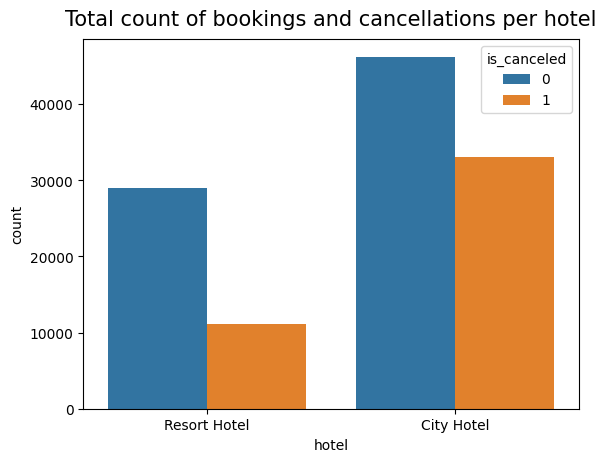

Cancellations in resort hotel=  0.27763354967548676
Cancellations in city hotel=  0.41726963317786464


Text(0.5, 1.0, 'Total count of bookings and cancellations per hotel')

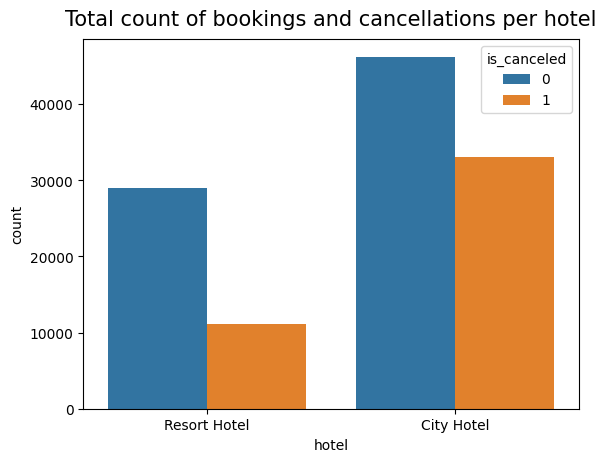

In [ ]:
sns.countplot( data=df, x = 'hotel', hue = 'is_canceled')
resort_canceled = df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 1)]
city_canceled = df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 1)]

print('Cancellations in resort hotel= ', (len(resort_canceled)) / (len(df[df['hotel'] == 'Resort Hotel'])))
print('Cancellations in city hotel= ', (len(city_canceled)) / (len(df[df['hotel'] == 'City Hotel'])))

plt.title("Total count of bookings and cancellations per hotel", fontsize = 15, pad = 10)

* city hotels have higher cancellation rate than resort hotels

Cancelations among new guests=  0.3778508392455442
Cancelations among old guests=  0.14488188976377953


Text(0.5, 1.0, 'Total count of is repeated guest')

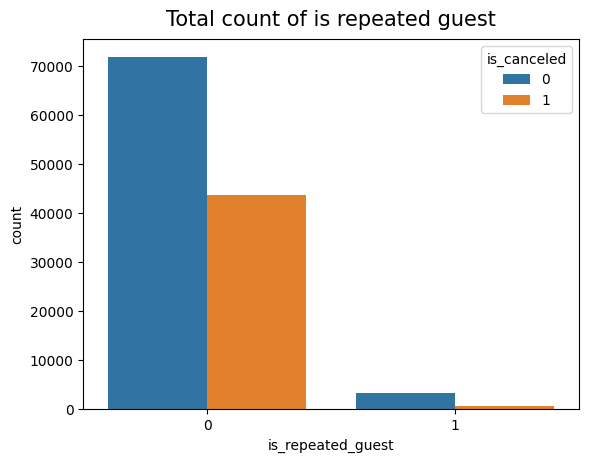

Cancelations among new guests=  0.3778508392455442
Cancelations among old guests=  0.14488188976377953


Text(0.5, 1.0, 'Total count of is repeated guest')

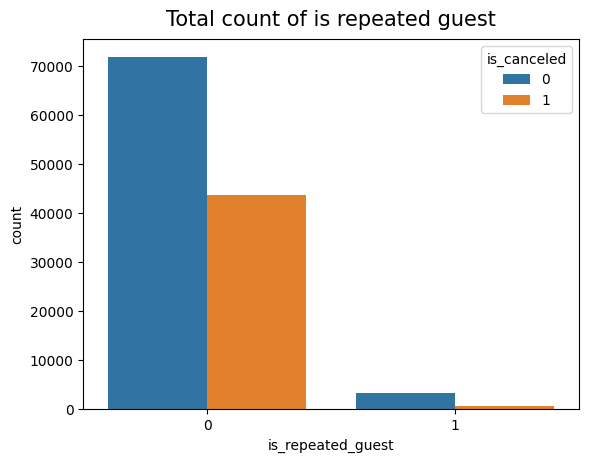

In [ ]:
# Visualize the repeated guest
sns.countplot(data = df, x ='is_repeated_guest', hue ='is_canceled')
new_guest = df[(df['is_repeated_guest'] == 0) & (df['is_canceled']==1)]
old_guest = df[(df['is_repeated_guest'] == 1) & (df['is_canceled']==1)]
print('Cancelations among new guests= ', (len(new_guest)) / (len(df[df['is_repeated_guest'] == 0])))
print('Cancelations among old guests= ', (len(old_guest)) / (len(df[df['is_repeated_guest'] == 1])))

plt.title("Total count of is repeated guest", fontsize = 15, pad = 10)

* maximum customers are new comers and they are less likely to cancel their current booking

Text(0.5, 1.0, 'Booking Changes VS Cancellations')

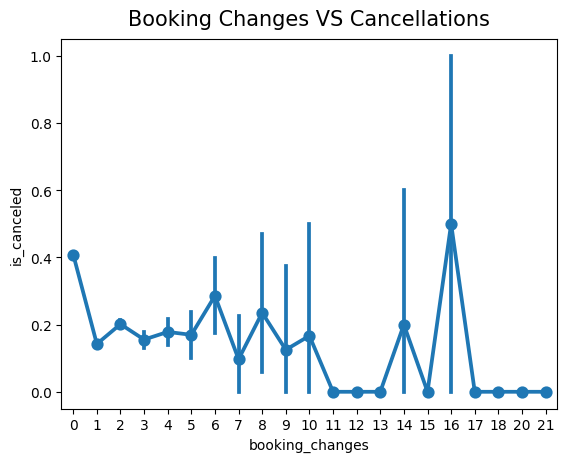

Text(0.5, 1.0, 'Booking Changes VS Cancellations')

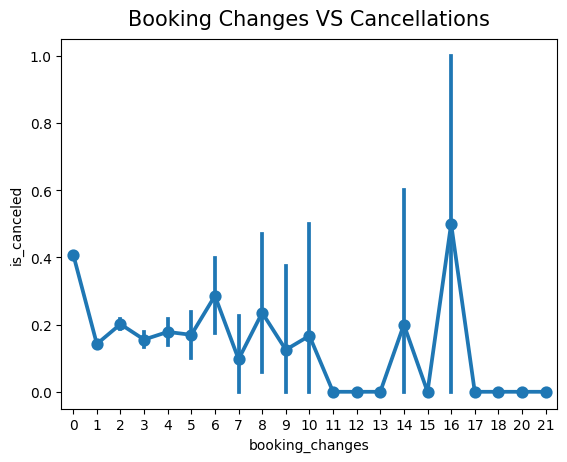

In [ ]:
sns.pointplot(data = df, x = 'booking_changes', y = 'is_canceled')
plt.title("Booking Changes VS Cancellations", fontsize = 15, pad = 10)

* the bookings does not hold as there is no trend in it's impact on the cancellation of bookings

Text(0.5, 1.0, 'Total number of bookings per year')

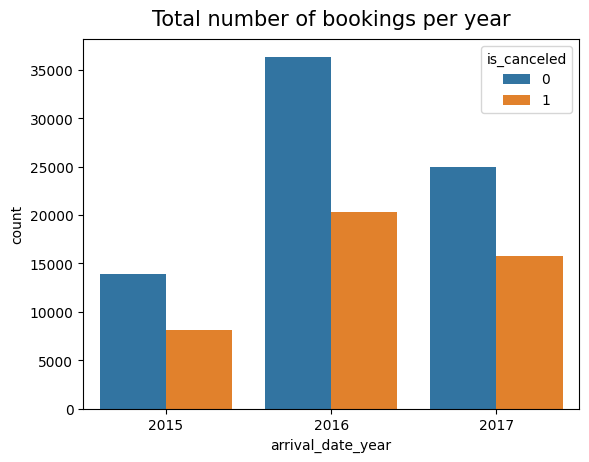

Text(0.5, 1.0, 'Total number of bookings per year')

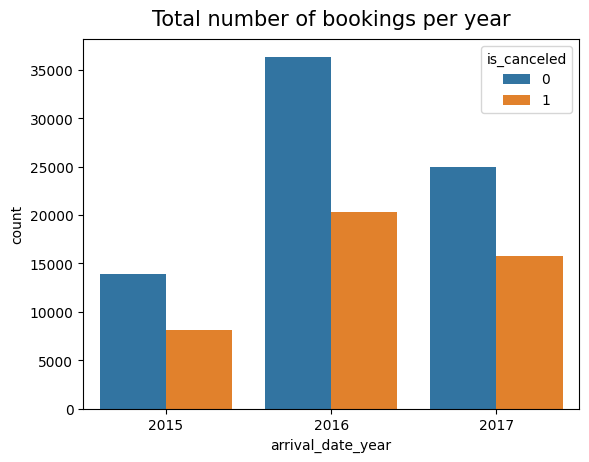

In [ ]:
sns.countplot(data = df, x = 'arrival_date_year', hue = 'is_canceled')
plt.title("Total number of bookings per year", fontsize = 15, pad = 10)

In [ ]:
year_cancelled = df.groupby(['arrival_date_year'])['is_canceled'].sum()
year_cancelled

,is_canceled
arrival_date_year,
2015,8142
2016,20337
2017,15745


,is_canceled
arrival_date_year,
2015,8142
2016,20337
2017,15745


Text(0.5, 1.0, 'Total Number of bookings per month')

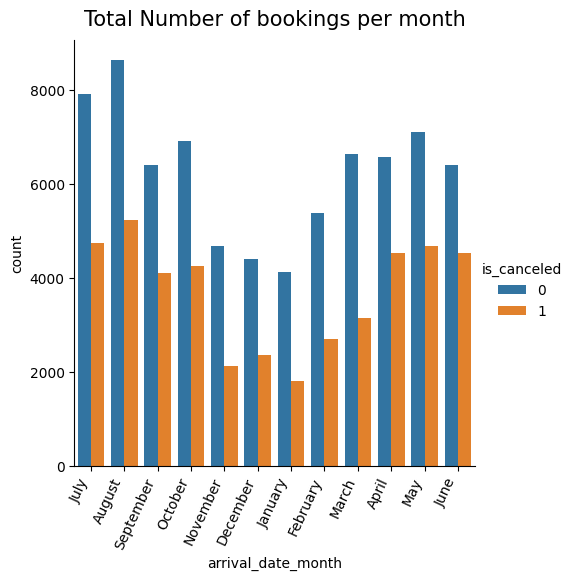

Text(0.5, 1.0, 'Total Number of bookings per month')

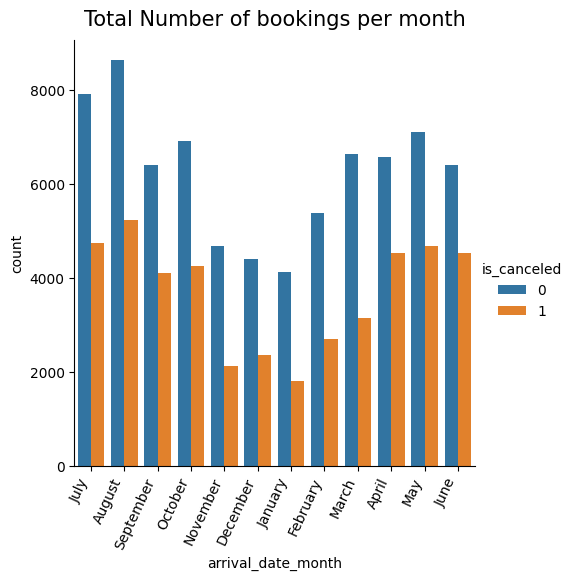

In [ ]:
book_mon = sns.catplot(data = df, x = 'arrival_date_month', hue = 'is_canceled', kind = 'count')
book_mon.set_xticklabels(rotation = 65, horizontalalignment = 'right')
plt.title("Total Number of bookings per month", fontsize = 15, pad = 10)

* Maximum bookings in the year 2016 were in the months of July and August

Text(0.5, 1.0, 'Distribution of cancellations in various channels')

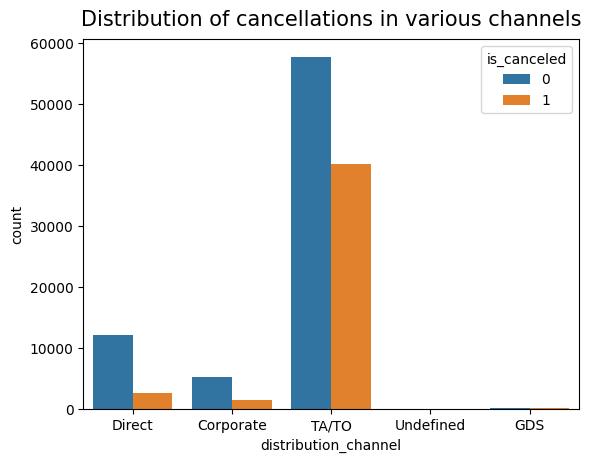

Text(0.5, 1.0, 'Distribution of cancellations in various channels')

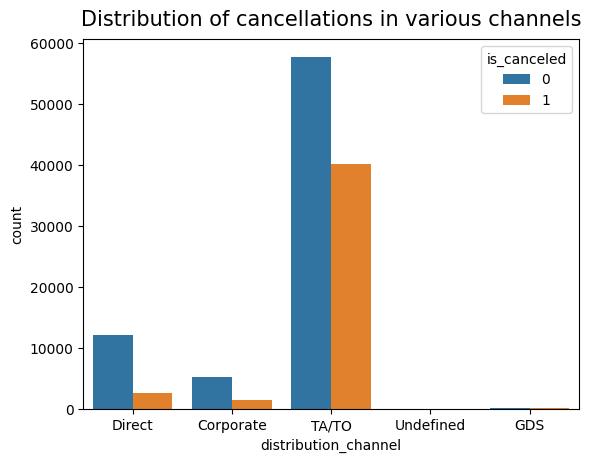

In [ ]:
sns.countplot(data = df, x = 'distribution_channel', hue = 'is_canceled')
plt.title("Distribution of cancellations in various channels", fontsize = 15, pad = 10)

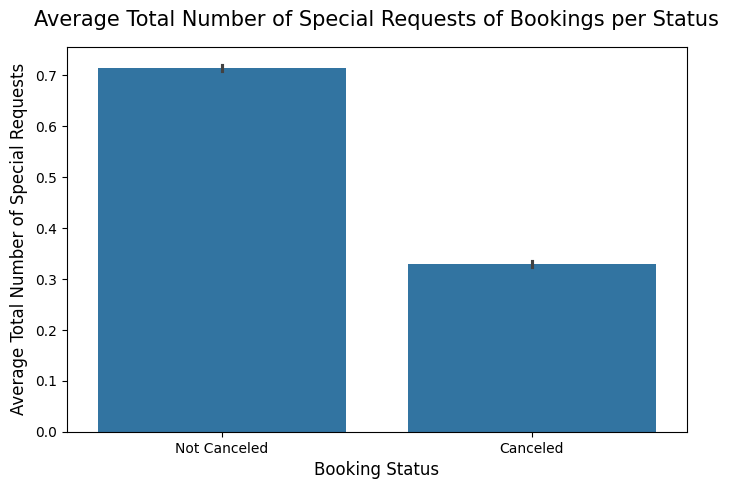

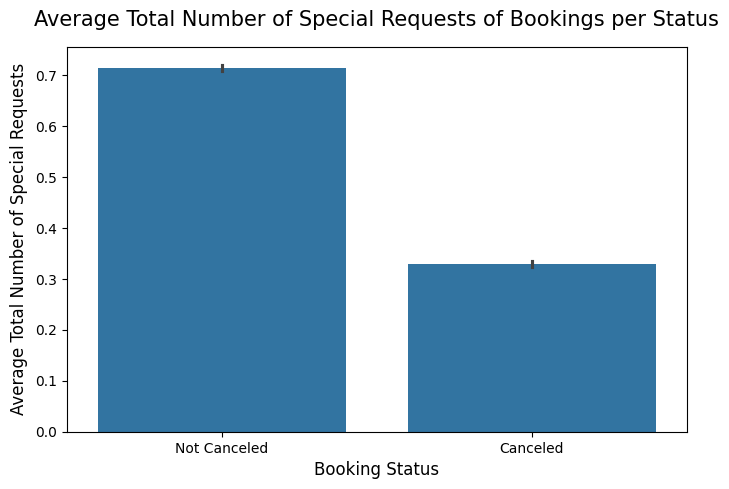

In [ ]:
plt.figure(figsize=(8,5))
plt.title("Average Total Number of Special Requests of Bookings per Status", fontsize = 15, pad = 15)
sns.barplot(x=df['is_canceled'], y=df['total_of_special_requests'])
plt.xlabel("Booking Status", fontsize = 12, labelpad = 4)
plt.ylabel("Average Total Number of Special Requests", fontsize = 12, labelpad = 5)
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled']);

In [ ]:
import warnings
warnings.filterwarnings('ignore')

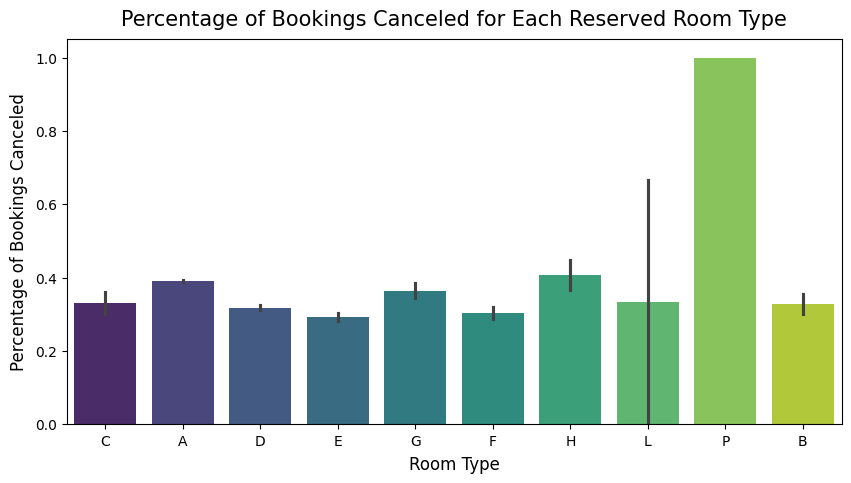

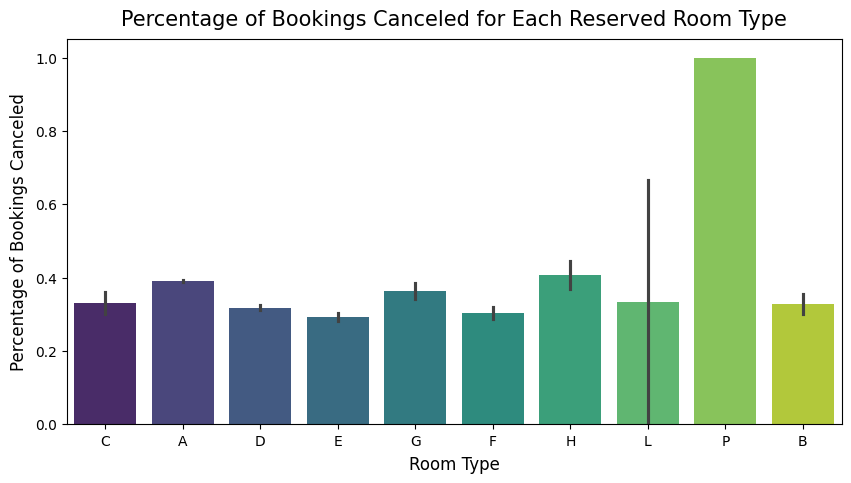

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Percentage of Bookings Canceled for Each Reserved Room Type", fontsize = 15, pad = 10)
sns.barplot(x=df['reserved_room_type'], y=df['is_canceled'],palette='viridis')
plt.xlabel("Room Type", fontsize = 12, labelpad = 5)
plt.ylabel("Percentage of Bookings Canceled", fontsize = 12, labelpad = 5);

Customers who reserved room type P have the highest percentage booking cancellation with 100% of bookings canceled. As the dataset did not provide the actual room designations for anonymity purposes, it is hard to interpret why bookings of room type P are canceled more often

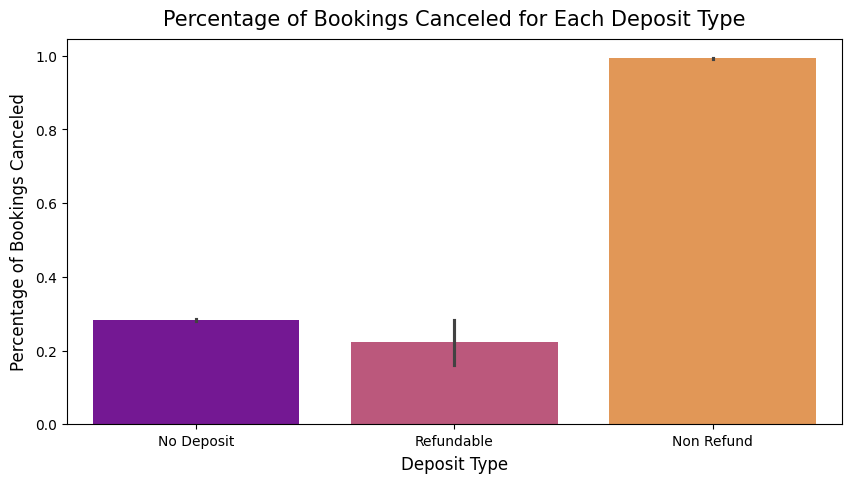

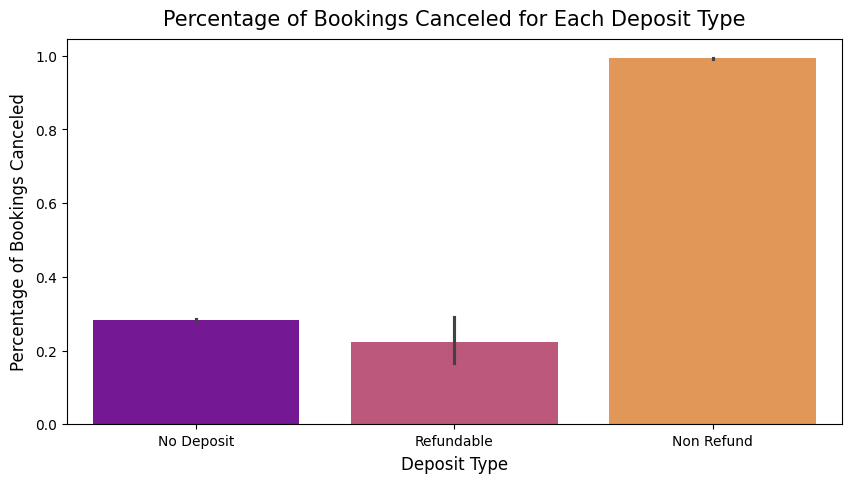

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Percentage of Bookings Canceled for Each Deposit Type", fontsize = 15, pad = 10)
sns.barplot(x=df['deposit_type'], y=df['is_canceled'],palette='plasma')
plt.xlabel("Deposit Type", fontsize = 12, labelpad = 5)
plt.ylabel("Percentage of Bookings Canceled", fontsize = 12, labelpad = 5);

customers who pay a non-refundable deposit have a much higher percentage of canceled reservations.it is necessary to dig a little deeper into the characteristics of bookings with a non-refundable deposit

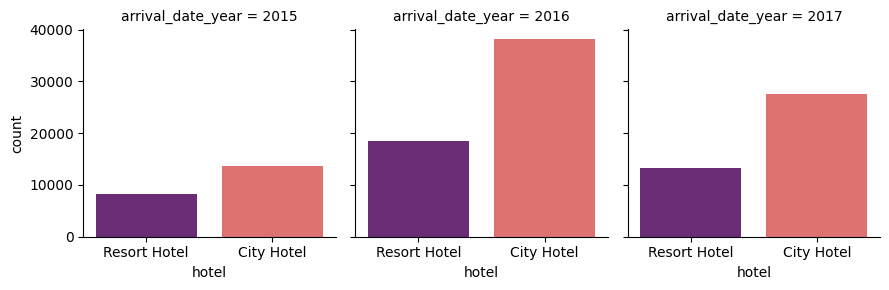

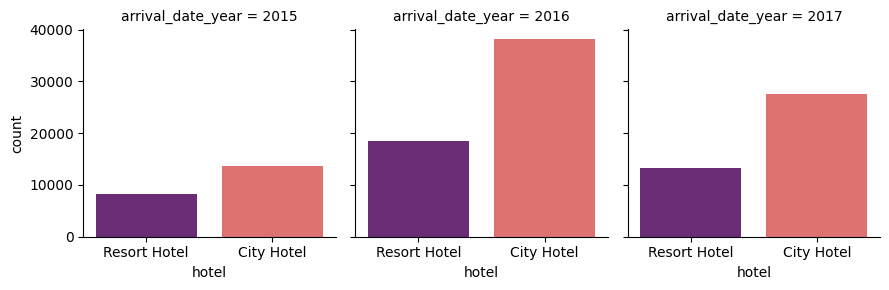

In [ ]:
grid = sns.FacetGrid(data=df, col='arrival_date_year')
grid.map(sns.countplot, 'hotel', palette='magma')

all three years city hotels has more bookings than resort hotel

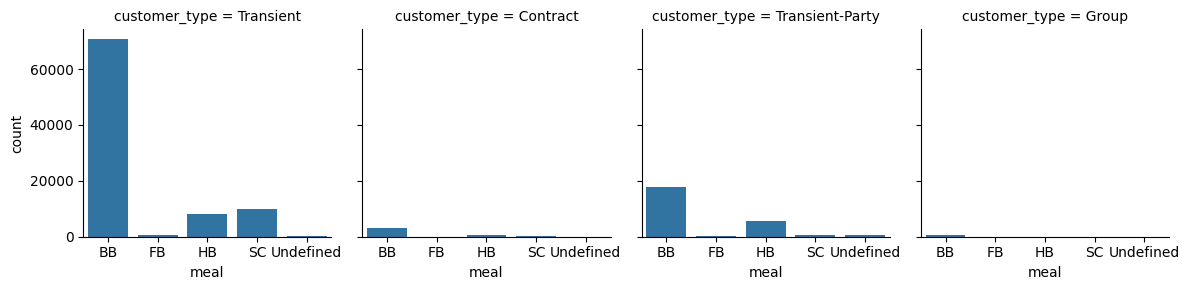

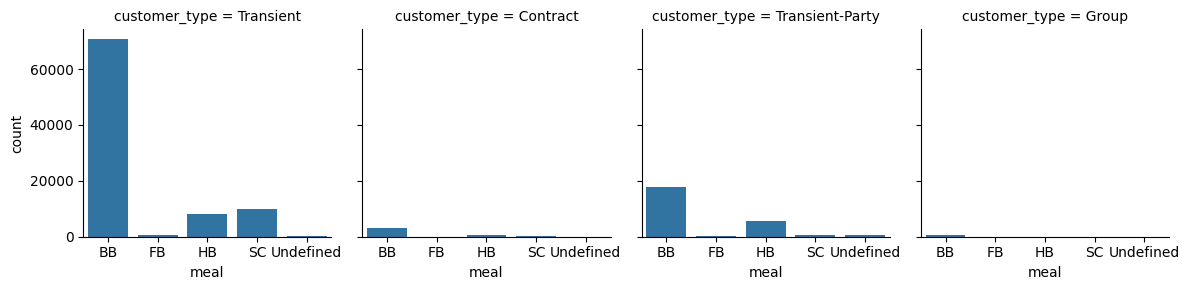

In [ ]:
df['meal'].nunique(), df['customer_type'].nunique()
grid = sns.FacetGrid(data=df, col ='customer_type', palette ='tab10')
grid.map(sns.countplot, 'meal')

 all kinds of customers prefer BB type meals

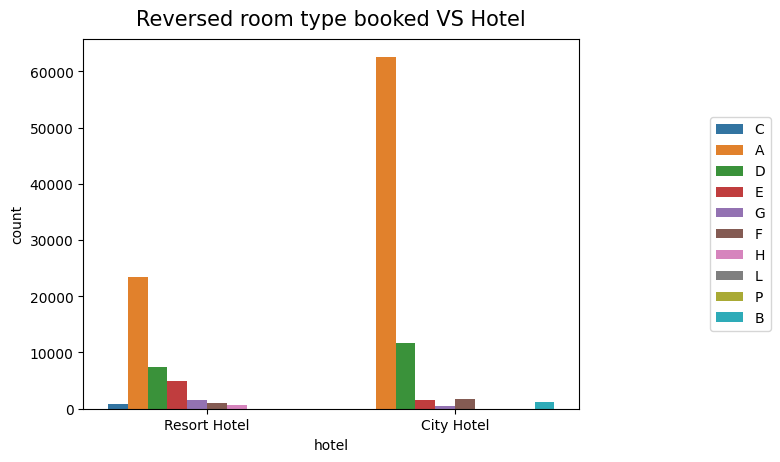

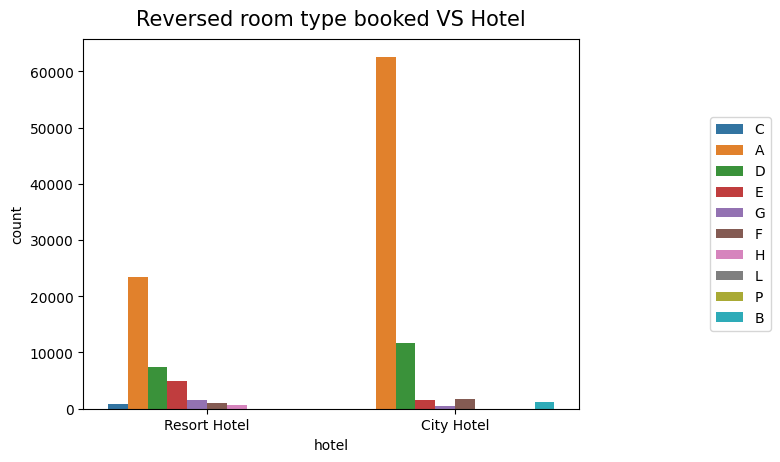

In [ ]:
g = sns.countplot(data = df, x = 'hotel', hue = 'reserved_room_type')
g.legend(loc = 'center left', bbox_to_anchor = (1.25, 0.5), ncol = 1)
plt.title("Reversed room type booked VS Hotel", fontsize = 15, pad = 10)
plt.show()

# preprocessing the dataset

In [ ]:
df = df[(df['adults'] > 0) | (df['babies'] > 0)]
df['children'] = df['children'].fillna(0)

# Replace missing values with mode()
df['country'] = df['country'].fillna(df['country'].mode()[0])

df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

In [ ]:
df.dropna(subset=['meal'], inplace=True)

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# create a new column with existing cols
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [ ]:
# maping the month with #number
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4,'May': 5, 'June': 6, 'July': 7, 'August': 8,'September': 9, 'October': 10, 'November': 11, 'December': 12}
df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

In [ ]:
df['reservation_status_encoded'] = df['reservation_status'].map({'Canceled': 1, 'Check-Out': 0, 'No-Show': 2})
df['has_weekend_stay'] = (df['stays_in_weekend_nights'] > 0).astype(int)

In [ ]:
# drop the unwanted columns
drop_cols = ['company', 'agent', 'reservation_status_date', 'reservation_status']
df.drop(columns=drop_cols, inplace=True)

In [ ]:
# encode the category data using one hot encoding
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
df_encoded.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,7,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,7,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False


# Skewness analysis

In [ ]:
skewness = df_numeric.skew()
skewness

,0
is_canceled,3.160312
lead_time,3.058796
arrival_date_year,1.210897
arrival_date_week_number,-1.572404
arrival_date_day_of_month,1.148081
stays_in_weekend_nights,1.589074
stays_in_week_nights,1.069057
adults,0.664830
children,6.924722
babies,0.000000


,0
is_canceled,3.160312
lead_time,3.058796
arrival_date_year,1.210897
arrival_date_week_number,-1.572404
arrival_date_day_of_month,1.148081
stays_in_weekend_nights,1.589074
stays_in_week_nights,1.069057
adults,0.664830
children,6.924722
babies,0.000000


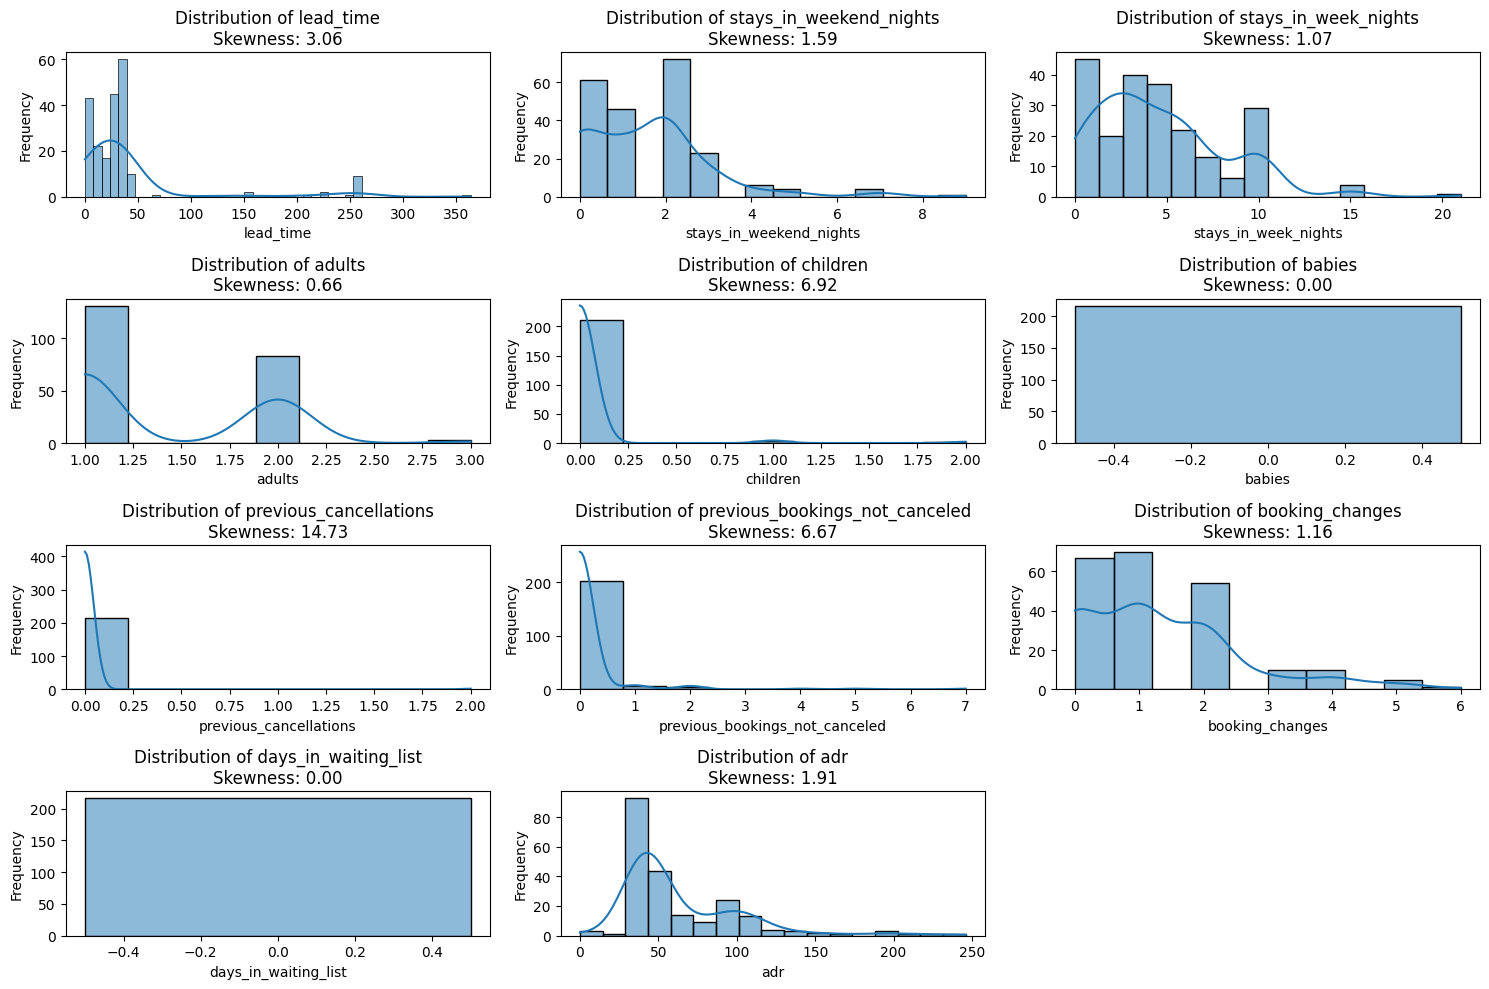

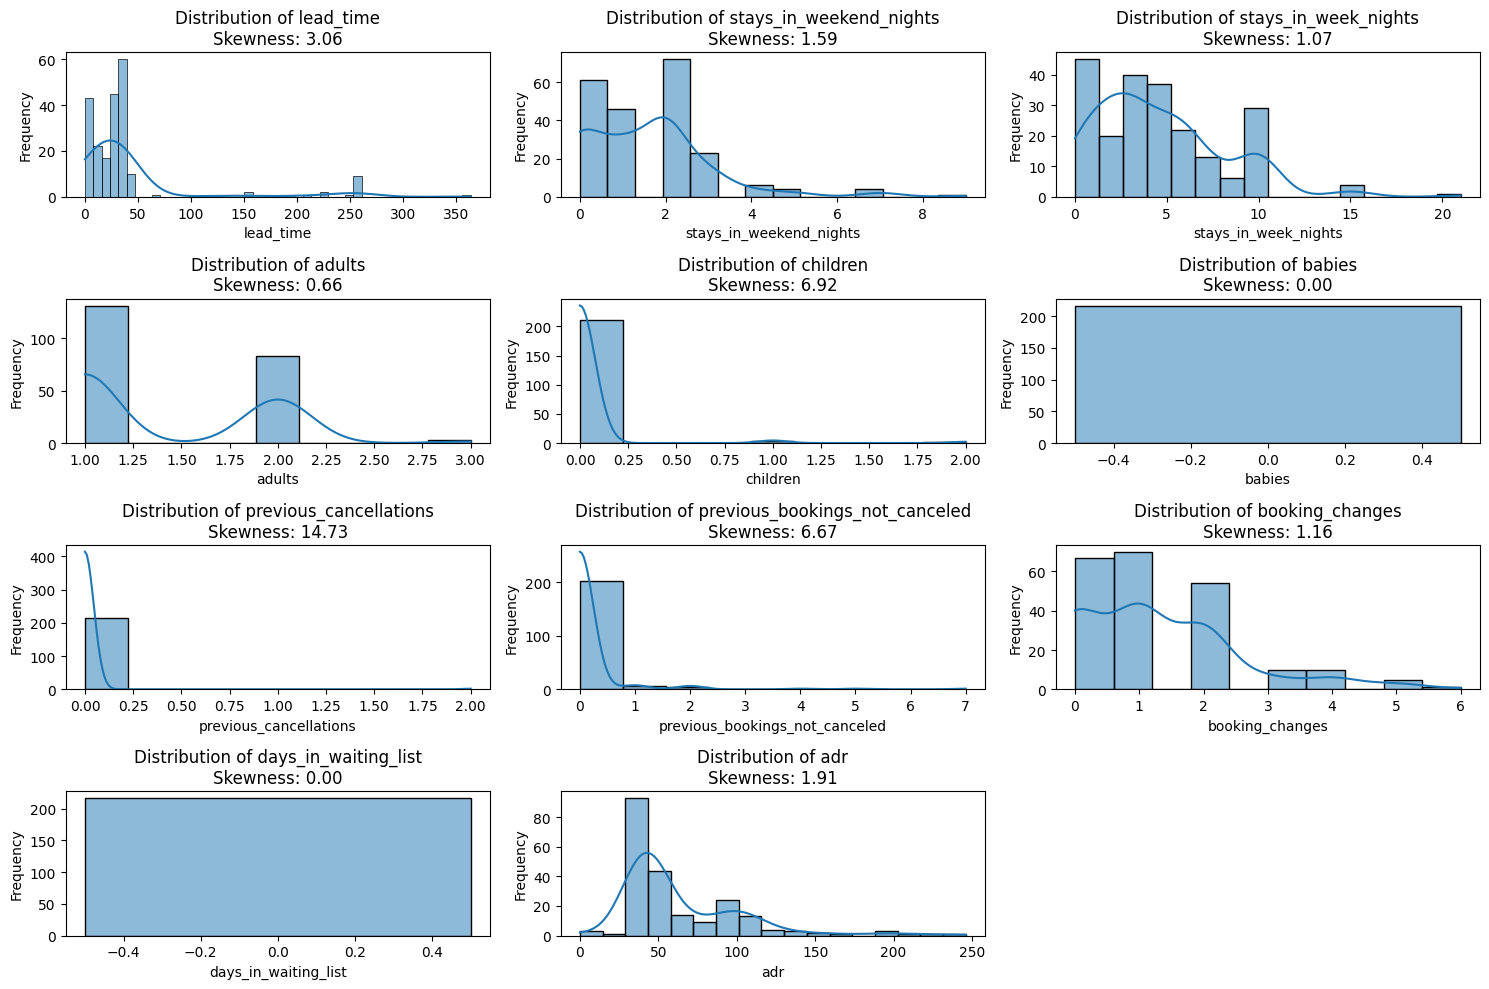

In [ ]:
plt.figure(figsize=(15, 10))
numerical_cols_to_plot = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr']

for i, col in enumerate(numerical_cols_to_plot):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df_numeric[col], kde=True)
    plt.title(f'Distribution of {col}\nSkewness: {skewness[col]:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# handling outliers using IQR Method

In [ ]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [ ]:
df.shape

(53037, 33)

(53037, 33)

In [ ]:
# skewness
for col in numerical_cols:
    skew = df[col].skew()
    print(f"{col}: {skew:.2f}")

is_canceled: 0.42
lead_time: 0.98
arrival_date_year: -0.29
arrival_date_week_number: 0.10
arrival_date_day_of_month: 0.03
stays_in_weekend_nights: 0.20
stays_in_week_nights: 0.43
adults: 0.00
children: 0.00
babies: 0.00
is_repeated_guest: 0.00
previous_cancellations: 0.00
previous_bookings_not_canceled: 0.00
booking_changes: 0.00
days_in_waiting_list: 0.00
adr: 0.34
required_car_parking_spaces: 0.00
total_of_special_requests: 0.91
total_guests: 0.00
total_stay: 0.74
arrival_month_num: 0.09
reservation_status_encoded: 0.58
has_weekend_stay: -0.35
is_canceled: 0.42
lead_time: 0.98
arrival_date_year: -0.29
arrival_date_week_number: 0.10
arrival_date_day_of_month: 0.03
stays_in_weekend_nights: 0.20
stays_in_week_nights: 0.43
adults: 0.00
children: 0.00
babies: 0.00
is_repeated_guest: 0.00
previous_cancellations: 0.00
previous_bookings_not_canceled: 0.00
booking_changes: 0.00
days_in_waiting_list: 0.00
adr: 0.34
required_car_parking_spaces: 0.00
total_of_special_requests: 0.91
total_guests:

Skewness has been reduced which means the data is more symmetric

In [ ]:
numerical_cols_encoded = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
df_filtered = df_encoded.copy()

for col in numerical_cols_encoded:
    Q1 = df_filtered[col].quantile(0.25)
    Q3 = df_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df_filtered[(df_filtered[col] >= lower_bound) & (df_filtered[col] <= upper_bound)]

# Feature selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier
x = df_filtered.drop('is_canceled', axis=1)
y = df_filtered['is_canceled']

In [ ]:
model = RandomForestClassifier(random_state=32)
model.fit(x, y)

RandomForestClassifier(random_state=32)

RandomForestClassifier(random_state=32)

In [ ]:
importances = pd.Series(model.feature_importances_, index=x.columns)
importances_sorted = importances.sort_values(ascending=False)

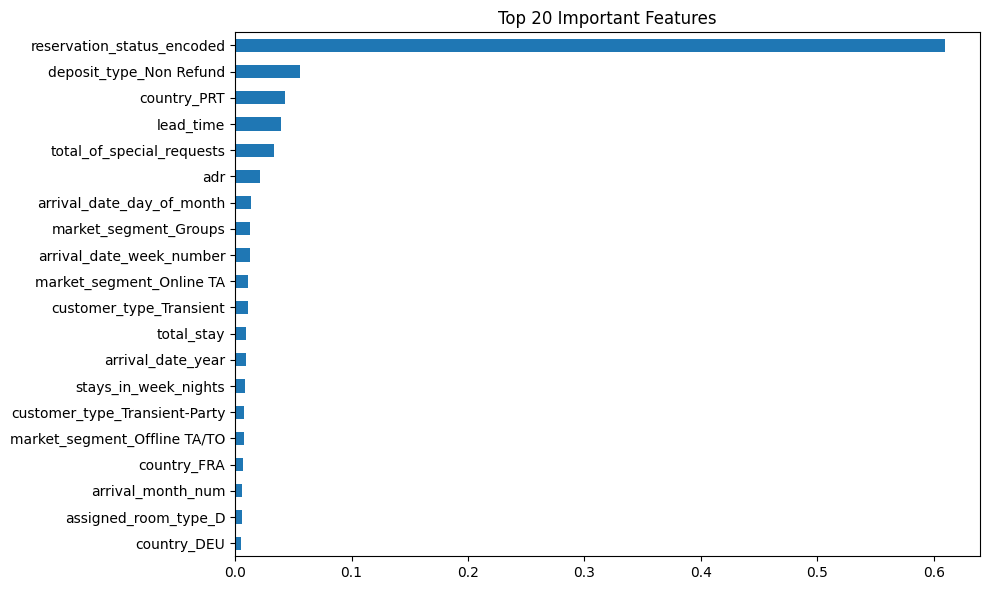

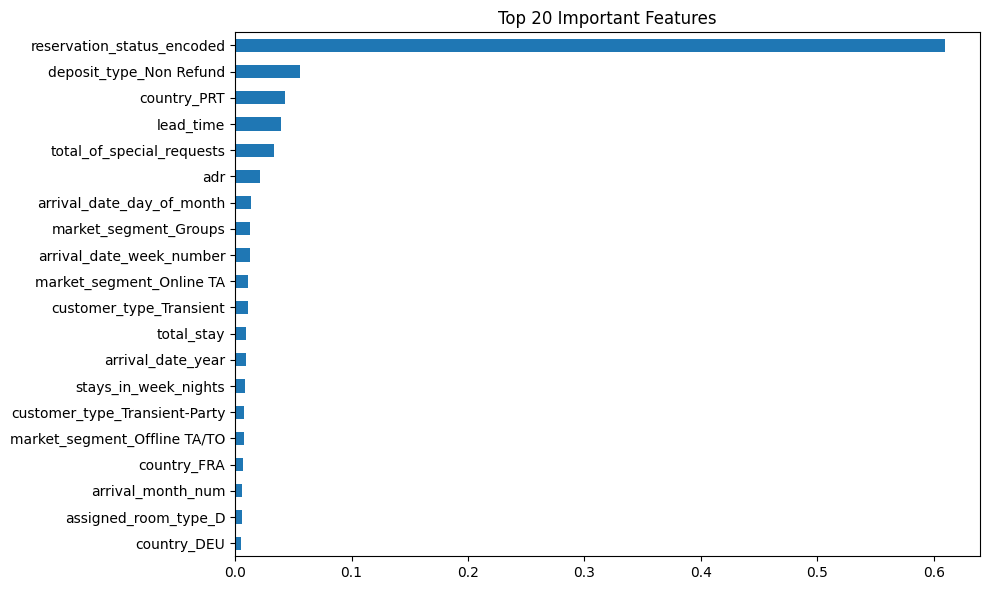

In [ ]:
plt.figure(figsize=(10, 6))
importances_sorted.head(20).plot(kind='barh')
plt.title("Top 20 Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
x_high_var = selector.fit_transform(x)
high_var_cols = x.columns[selector.get_support()]

In [ ]:
x1 = pd.DataFrame(x_high_var, columns=high_var_cols)
corr_matrix = x1.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# correlation analysis

In [ ]:
to_droped = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
print("Dropping highly correlated features:", to_droped)

Dropping highly correlated features: ['arrival_month_num', 'distribution_channel_Direct', 'distribution_channel_TA/TO', 'customer_type_Transient-Party']
Dropping highly correlated features: ['arrival_month_num', 'distribution_channel_Direct', 'distribution_channel_TA/TO', 'customer_type_Transient-Party']


In [ ]:
x1.head()

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests,total_stay,arrival_month_num,...,distribution_channel_TA/TO,reserved_room_type_D,reserved_room_type_E,assigned_room_type_B,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,deposit_type_Non Refund,customer_type_Transient,customer_type_Transient-Party
0,14.0,2015.0,27.0,1.0,0.0,2.0,98.0,1.0,2.0,7.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,14.0,2015.0,27.0,1.0,0.0,2.0,98.0,1.0,2.0,7.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,2015.0,27.0,1.0,0.0,2.0,107.0,0.0,2.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,9.0,2015.0,27.0,1.0,0.0,2.0,103.0,1.0,2.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,85.0,2015.0,27.0,1.0,0.0,3.0,82.0,1.0,3.0,7.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests,total_stay,arrival_month_num,...,distribution_channel_TA/TO,reserved_room_type_D,reserved_room_type_E,assigned_room_type_B,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,deposit_type_Non Refund,customer_type_Transient,customer_type_Transient-Party
0,14.0,2015.0,27.0,1.0,0.0,2.0,98.0,1.0,2.0,7.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,14.0,2015.0,27.0,1.0,0.0,2.0,98.0,1.0,2.0,7.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,2015.0,27.0,1.0,0.0,2.0,107.0,0.0,2.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,9.0,2015.0,27.0,1.0,0.0,2.0,103.0,1.0,2.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,85.0,2015.0,27.0,1.0,0.0,3.0,82.0,1.0,3.0,7.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
x1 = x1.drop(columns=to_droped)

# Model builing and Evaluation

In [ ]:
# importing modules
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score,precision_score,recall_score

# split data for traing and testing

In [ ]:
x = df_filtered.drop(['is_canceled','reservation_status_encoded'], axis=1)
y = df_filtered['is_canceled']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,)

In [ ]:
scaler =StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Build the Multiple Machine learning Model

In [ ]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=28),
    'Decision Tree': DecisionTreeClassifier(random_state=32),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=43),
    'SVM': SVC(random_state=33)
}

In [ ]:
results = {}
for name, clf in classifiers.items():
    clf.fit(x_train_scaled, y_train)
    y_train_pred = clf.predict(x_train_scaled)
    y_test_pred = clf.predict(x_test_scaled)


    accuracy = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    results[name] = {'accuracy': accuracy, 'f1_score': f1}
    print(f"{name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

Logistic Regression - Accuracy: 0.7823, F1-Score: 0.7081
Decision Tree - Accuracy: 0.8260, F1-Score: 0.7839
Random Forest - Accuracy: 0.8603, F1-Score: 0.8167
XGBoost - Accuracy: 0.8484, F1-Score: 0.8069
SVM - Accuracy: 0.8133, F1-Score: 0.7501


# Model Evaluation and Comparison

In [ ]:
best_model = max(results, key=lambda x: results[x]['f1_score'])
print(f"\nBest Model: {best_model} with F1-Score: {results[best_model]['f1_score']:.4f}")


Best Model: Random Forest with F1-Score: 0.8167

Best Model: Random Forest with F1-Score: 0.8167


In [ ]:
best_model1 = classifiers[best_model]
best_model1.fit(x_train_scaled, y_train)
y_test_pred = best_model1.predict(x_test_scaled)

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

[[5825  518]
 [ 964 3301]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      6343
           1       0.86      0.77      0.82      4265

    accuracy                           0.86     10608
   macro avg       0.86      0.85      0.85     10608
weighted avg       0.86      0.86      0.86     10608

[[5825  518]
 [ 964 3301]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      6343
           1       0.86      0.77      0.82      4265

    accuracy                           0.86     10608
   macro avg       0.86      0.85      0.85     10608
weighted avg       0.86      0.86      0.86     10608



In [ ]:
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1-Score: {f1:.4f}")

Test Accuracy: 0.8603
Test F1-Score: 0.8167
Test Accuracy: 0.8603
Test F1-Score: 0.8167


# cross validation

In [ ]:
# K-Fold cross validation

from sklearn.model_selection import KFold,cross_val_score
k = 6
cv = KFold(n_splits=k, shuffle=True, random_state=10)
scores = cross_val_score(model, x, y, cv=cv, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.8658371  0.86651584 0.86459276 0.86582193 0.86288042 0.86197534]
Mean accuracy: 0.8646038966379801
Cross-validation scores: [0.8658371  0.86651584 0.86459276 0.86582193 0.86288042 0.86197534]
Mean accuracy: 0.8646038966379801
